In [31]:
import numpy as np
import matplotlib.pyplot as plt

In [32]:
# CONSTANTS
G = 6.674e-11
M_earth = 5.9722e24
mu_earth = G * M_earth
R_earth = 6.371e6
ALTITUDE = 400_000

def calculate_initial_conditions(altitude):
    r_orbit = R_earth + altitude
    v_circ = np.sqrt(mu_earth / r_orbit)
    r0 = np.array([r_orbit, 0.0])
    v0 = np.array([0.0, v_circ])
    return r0, v0

In [33]:
r0, v0 = calculate_initial_conditions(ALTITUDE)
initial_state = np.concatenate([r0,v0])
print(f"Starting point is {r0}")
print(f"Initial Velocity is {v0}")
print(f"Initial State is {initial_state}")

Starting point is [6771000.       0.]
Initial Velocity is [   0.         7672.44644817]
Initial State is [6771000.               0.               0.            7672.44644817]


In [34]:
def acceleration(r):
    # Satellite mass cancels in F=ma — result independent of satellite mass
    # Dividing by r_mag^3 combines magnitude (GM/r^2) and unit direction
    r_mag = np.linalg.norm(r)
    return -(mu_earth / r_mag**3) * r    # Negative sign: acceleration points towards Earth

In [35]:
# Simulation parameters
num_orbits = 5
dt = 10.0
r_orbit = R_earth + ALTITUDE
T_kepler = 2 * np.pi * np.sqrt(r_orbit**3 / mu_earth)
print(f"Period of an orbit is {T_kepler:.1f} s ({T_kepler/60:.2f} min)")
steps = round((num_orbits * T_kepler) / dt)
print(f"Steps: {steps}")

Period of an orbit is 5545.0 s (92.42 min)
Steps: 2772


In [36]:
# r0 and v0 combined into a single 4-element state vector for RK4: [x, y, vx, vy]

def deriv(state):

    # Extracts position (first two elements) and velocity (last 2 elements)
    r = state[:2]
    v = state[2:]

    # Computes acceleration based on current position
    a = acceleration(r)

    # Returns the derivative of the state: [vx, vy, ax, ay]
    return np.concatenate([v, a])


In [37]:
def euler_step(state, dt):
    r = state[:2]
    v = state[2:]
    a = acceleration(r)

    r_new = r + v * dt
    v_new = v + a * dt
    return np.concatenate([r_new, v_new])

In [38]:
# RK4 Integration
def rk4step(state, dt):

    # Calculates the four slopes (k1, k2, k3, k4) using the derivative function
    k1 = deriv(state)
    k2 = deriv(state + 0.5 * dt * k1)
    k3 = deriv(state + 0.5 * dt * k2)
    k4 = deriv(state + dt * k3)
    
    # Returns new state by using weighted average of the slopes
    return state + (dt / 6) * (k1 + 2*k2 + 2*k3 + k4)

In [39]:
def propagate(initial_state, dt, steps, method="rk4"):
    step_func = rk4step if method=="rk4" else euler_step
    states = np.zeros((steps, len(initial_state)))
    s = initial_state.copy()

    for i in range(steps):
        states[i] = s
        s = step_func(s, dt)
    return states

positions = propagate(initial_state, 10, steps, method="euler")[:, :2]
print(positions)

[[ 6771000.                0.        ]
 [ 6771000.            76724.46448172]
 [ 6770130.60944469   153448.92896345]
 ...
 [-7778997.32876515 -6388829.97778824]
 [-7740656.72122145 -6438155.40474702]
 [-7702012.13897765 -6487231.17964984]]


In [40]:
def specific_energy(r, v):
    KE = 0.5 * np.dot(v, v)
    PE = -mu_earth / np.linalg.norm(r)
    return KE + PE

In [41]:
def angular_momentum(r, v):
    return r[0]*v[1] - r[1]*v[0]

In [42]:
# Running both propagators
states_rk4 = propagate(initial_state, 10, steps, method="rk4")
states_euler = propagate(initial_state, 10, steps, method="euler")

# Extracting positions and velocities form both methods
r_rk4, v_rk4 = states_rk4[:, :2], states_rk4[:, 2:]
r_euler, v_euler = states_euler[:, :2], states_euler[:, 2:]

# Calculating initial values
E0 = specific_energy(initial_state[:2], initial_state[2:])
h0 = angular_momentum(initial_state[:2], initial_state[2:])

# Relative errors in energy and angular momentum
energy_error_rk4 = np.array([(specific_energy(r, v) - E0) / abs(E0) for r, v in zip(r_rk4, v_rk4)])
energy_error_eul = np.array([(specific_energy(r, v) - E0) / abs(E0) for r, v in zip(r_euler, v_euler)])

angular_momentum_error_rk4 = np.array([(angular_momentum(r, v) - h0) / abs(h0) for r, v in zip(r_rk4, v_rk4)])
angular_momentum_error_eul = np.array([(angular_momentum(r, v) - h0) / abs(h0) for r, v in zip(r_euler, v_euler)])

time_array = np.arange(steps) * dt / 3600

print(f"rk4 coordinates: {r_rk4}")
print(f"rk4 x coordinates: {r_rk4[:,0]}")


rk4 coordinates: [[6771000.               0.        ]
 [6770565.30937344   76722.82258922]
 [6769261.29330727  153435.79413965]
 ...
 [6765728.6498905  -267126.97559107]
 [6768321.13796316 -190446.73388205]
 [6770044.58874236 -113742.03923844]]
rk4 x coordinates: [6771000.         6770565.30937344 6769261.29330727 ... 6765728.6498905
 6768321.13796316 6770044.58874236]


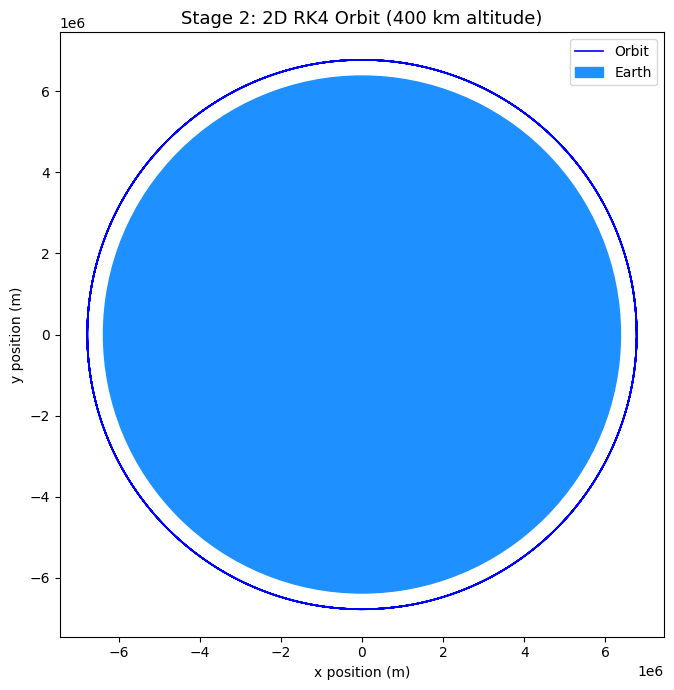

In [43]:
# plot to vizualize RK4
#print(positions[:,0])
x_coords = r_rk4[:, 0]
y_coords = r_rk4[:, 1]

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(x_coords, y_coords, color="blue", lw=1.2, label="Orbit")

# Earth — Radius 6,371,000m
earth = plt.Circle((0,0), R_earth, color="dodgerblue", label="Earth")
ax.add_patch(earth)

ax.set_aspect("equal")
ax.set_title(f"Stage 2: 2D RK4 Orbit ({ALTITUDE/1000:.0f} km altitude)", fontsize=13)
ax.set_xlabel("x position (m)", fontsize=10)
ax.set_ylabel("y position (m)", fontsize=10)
ax.legend()
plt.tight_layout()
plt.savefig("../images/stage2_RK4_orbit.png", dpi=150, bbox_inches="tight")
plt.show()

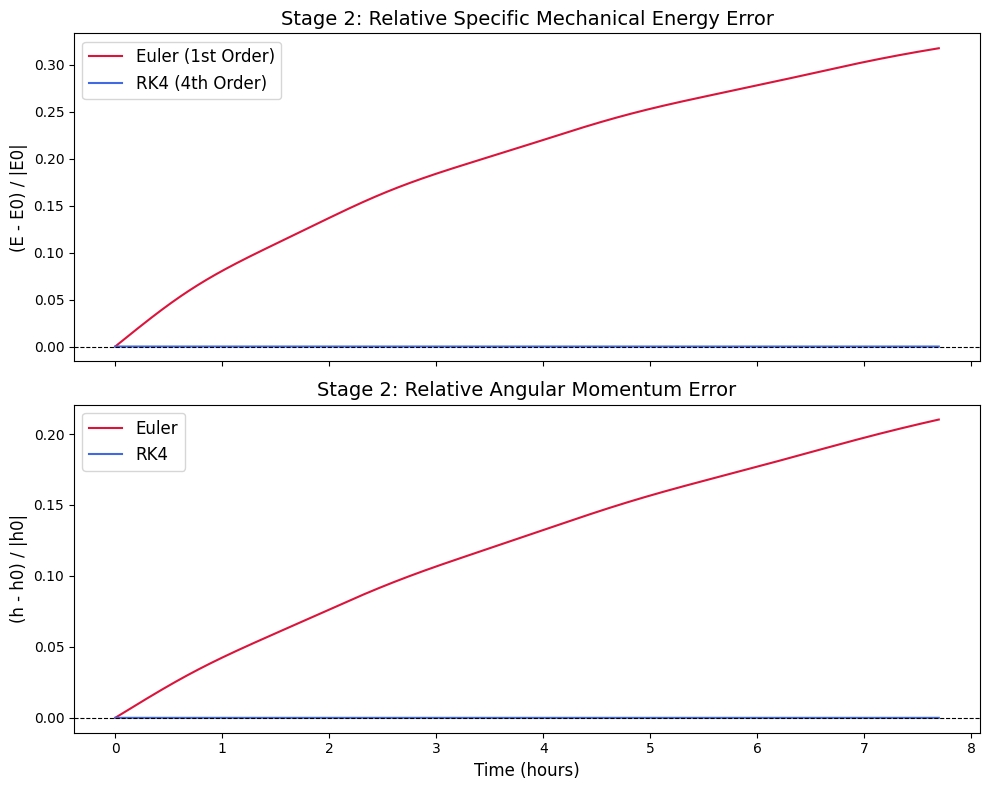

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Panel 1: Specific Energy Relative Error
ax1.plot(time_array, energy_error_eul, color='crimson', lw=1.5, label='Euler (1st Order)')
ax1.plot(time_array, energy_error_rk4, color='royalblue', lw=1.5, label='RK4 (4th Order)')
ax1.set_title('Stage 2: Relative Specific Mechanical Energy Error', fontsize=14)
ax1.set_ylabel('(E - E0) / |E0|', fontsize=12)
ax1.axhline(0, color='black', ls='--', lw=0.8)
ax1.legend(fontsize=12)

# Panel 2: Angular Momentum Relative Error
ax2.plot(time_array, angular_momentum_error_eul, color='crimson', lw=1.5, label='Euler')
ax2.plot(time_array, angular_momentum_error_rk4, color='royalblue', lw=1.5, label='RK4')
ax2.set_title('Stage 2: Relative Angular Momentum Error', fontsize=14)
ax2.set_xlabel('Time (hours)', fontsize=12)
ax2.set_ylabel('(h - h0) / |h0|', fontsize=12)
ax2.axhline(0, color='black', ls='--', lw=0.8)
ax2.legend(fontsize=12)

plt.tight_layout()
plt.savefig('../images/stage2_energy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

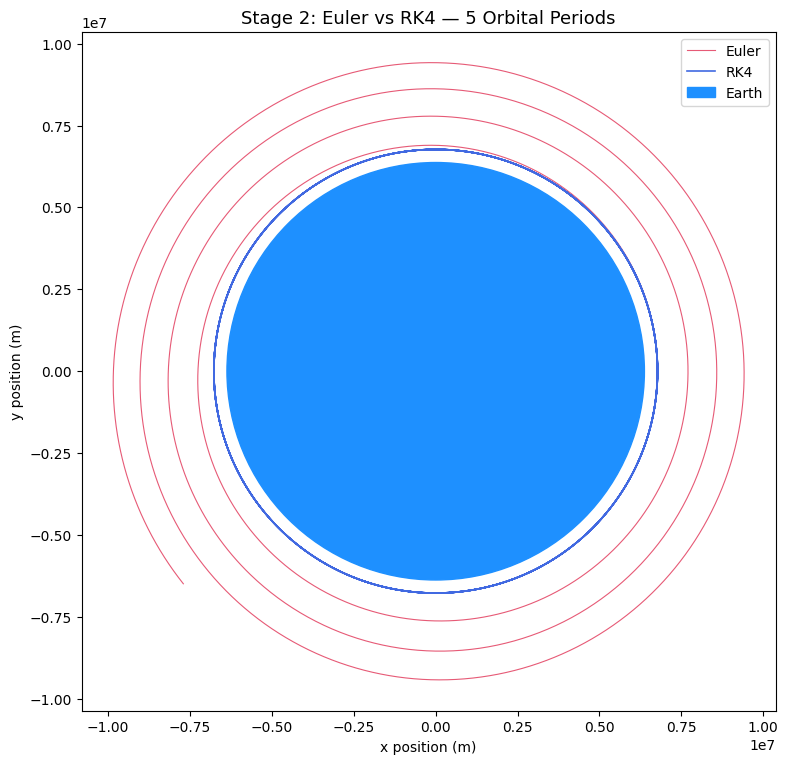

In [49]:
# ─────────────────────────────────────────────────
# ORBIT COMPARISON — RK4 CLOSED vs EULER SPIRAL
# ─────────────────────────────────────────────────

x_euler = states_euler[:, 0]
y_euler = states_euler[:, 1]
x_rk4 = states_rk4[:, 0]
y_rk4 = states_rk4[:, 1]

fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(x_euler, y_euler, color='crimson',   lw=0.8, alpha=0.7, label='Euler')
ax.plot(x_rk4,   y_rk4,   color='royalblue', lw=1.2, label='RK4')

earth = plt.Circle((0, 0), R_earth, color='dodgerblue', label='Earth')
ax.add_patch(earth)

ax.set_aspect('equal')
ax.set_title('Stage 2: Euler vs RK4 — 5 Orbital Periods', fontsize=13)
ax.set_xlabel('x position (m)', fontsize=10)
ax.set_ylabel('y position (m)', fontsize=10)
ax.legend()
plt.tight_layout()
plt.savefig('../images/stage2_orbit_comparison.png', dpi=150, bbox_inches='tight')
plt.show()